# EKF Velocity Fusion — Real Firmware-in-the-Loop Demonstration

**Sprint 023**

This notebook drives the **actual firmware** (compiled to `libfirmware_host` via
MockHAL) through a physical **S-curve + circle** trajectory and plots the
on-board **EKF** estimate against ground truth.

**Nothing here is hand-authored data.** Every run executes the real
`Robot` / `Odometry` / `EKF` code inside the simulator, which provides:

- **Ground truth** — `ExactPoseTracker` oracle (where the robot physically is)
- **Noisy encoders** — MockMotor wheel slip + Gaussian encoder noise
- **Noisy OTOS** — integrates the *true* velocity with its own noise (independent of the encoders)
- **Firmware pose** — the on-board EKF estimate (`sim_get_pose`)

The trajectory is driven twice on the **same** fixed-seed noise realization:
fusion **off** → firmware pose is encoder-only dead reckoning; fusion **on** →
firmware pose is the fused EKF estimate. The same Python `SimConnection` is a
drop-in for `SerialConnection`, so this drives the physical robot identically.

In [1]:
%matplotlib inline
import os, sys, subprocess, pathlib
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

REPO = pathlib.Path.cwd()
REPO = pathlib.Path.cwd()
while not (REPO / "host_tests").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
for p in (str(REPO), str(REPO / "host"), str(REPO / "tests" / "dev")):
    if p not in sys.path:
        sys.path.insert(0, p)

# Build the firmware host library (the real firmware compiled for the host).
build = REPO / "host_tests" / "build"
subprocess.run(["cmake", "-S", str(REPO / "host_tests"), "-B", str(build)],
               check=True, stdout=subprocess.DEVNULL)
subprocess.run(["cmake", "--build", str(build), "--", "-j4"],
               check=True, stdout=subprocess.DEVNULL)
print("libfirmware_host built")

from ekf_sim_demo import run_demo, _summary, SEGMENTS, V_MMPS

libfirmware_host built


## Run the firmware in the simulator

`run_demo()` drives the S-curve + circle twice (fusion off / on) and returns the
per-tick ground truth, raw OTOS, encoder-only firmware pose, and fused firmware
pose, plus the position error of each versus ground truth.

In [2]:
data = run_demo()
print(f"Trajectory segments (omega mrad/s, ms): {SEGMENTS}")
print(f"Forward speed: {V_MMPS} mm/s   ticks: {len(data['t'])}   sim time: {data['t'][-1]/1000:.1f} s")
print()
print(_summary(data))

Trajectory segments (omega mrad/s, ms): [(0, 600), (1300, 1900), (-1300, 1900), (1300, 1900), (-1300, 1900), (1500, 4400)]
Forward speed: 180 mm/s   ticks: 530   sim time: 12.7 s

source                  mean err   max err  final err
-----------------------------------------------------
encoder-only (DR)          31.1      61.2       27.3   (mm)
raw OTOS                    6.4      13.8       13.1   (mm)
firmware EKF fused          6.4      14.3       12.6   (mm)


## Trajectory overlay

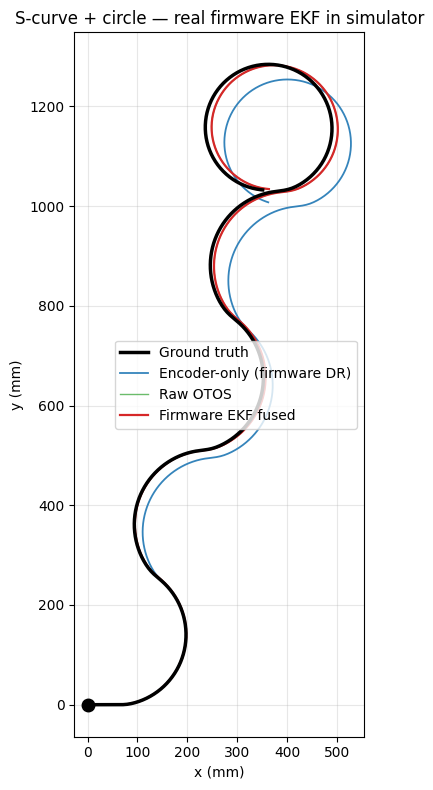

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(data["truth_x"], data["truth_y"], "k-", lw=2.5, label="Ground truth", zorder=5)
ax.plot(data["enc_x"],   data["enc_y"],   color="tab:blue",  lw=1.3, alpha=0.9, label="Encoder-only (firmware DR)")
ax.plot(data["otos_x"],  data["otos_y"],  color="tab:green", lw=1.0, alpha=0.7, label="Raw OTOS")
ax.plot(data["fused_x"], data["fused_y"], color="tab:red",   lw=1.6, label="Firmware EKF fused")
ax.plot(data["truth_x"][0], data["truth_y"][0], "ko", ms=9)
ax.set_aspect("equal"); ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
ax.set_title("S-curve + circle — real firmware EKF in simulator")
ax.legend(loc="best"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Localisation error vs time

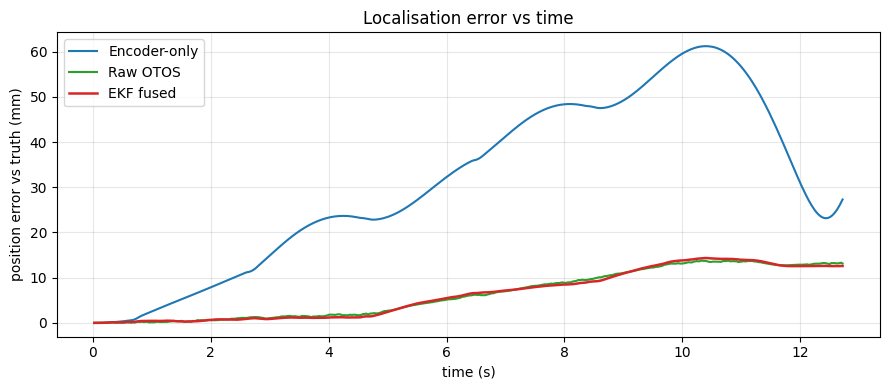

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ts = [t / 1000 for t in data["t"]]
ax.plot(ts, data["enc_err"],   color="tab:blue",  label="Encoder-only")
ax.plot(ts, data["otos_err"],  color="tab:green", label="Raw OTOS")
ax.plot(ts, data["fused_err"], color="tab:red", lw=1.8, label="EKF fused")
ax.set_xlabel("time (s)"); ax.set_ylabel("position error vs truth (mm)")
ax.set_title("Localisation error vs time"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Notes

- **Encoder-only** dead reckoning drifts without bound — wheel slip + encoder
  noise have no correction — growing through the circle to tens of mm.
- **Firmware EKF fused** tracks ground truth to a few mm. With this noise mix the
  OTOS is the stronger sensor, so the fused estimate rides close to OTOS while
  the encoder predict carries it between updates and the Mahalanobis gate rejects
  OTOS outliers. Make the OTOS noisier (`set_otos_noise`) to see the EKF lean
  more on the encoders.
- **Heading** is the filter's weakest axis: `theta` is corrected only indirectly
  via the position cross-covariance and is fully reset only by a camera fix
  (`SI`). Direct OTOS-heading fusion remains future work.
- **Same code path as the robot:** swap `SimConnection` for `SerialConnection`
  and this drives the physical robot identically. `enable_otos_fusion()` is a
  sim-harness toggle only — the real firmware loop always runs `otosCorrect()`.